## Import Data


In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

## Data reduction due to large number of dataset


In [158]:
pd.options.display.float_format = '{:.2f}'.format
df = pd.read_parquet('yellow_tripdata_2024-01.parquet')
print(len(df))
reduced_df = df.sample(n=10000,random_state=42)
reduced_df.to_csv('./reduced_dataset.csv', index=False)
# df.head()
print(len(reduced_df))
reduced_df.info()

2964624
10000
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1725696 to 1834261
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               10000 non-null  int32         
 1   tpep_pickup_datetime   10000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  10000 non-null  datetime64[us]
 3   passenger_count        9549 non-null   float64       
 4   trip_distance          10000 non-null  float64       
 5   RatecodeID             9549 non-null   float64       
 6   store_and_fwd_flag     9549 non-null   object        
 7   PULocationID           10000 non-null  int32         
 8   DOLocationID           10000 non-null  int32         
 9   payment_type           10000 non-null  int64         
 10  fare_amount            10000 non-null  float64       
 11  extra                  10000 non-null  float64       
 12  mta_tax                10000 non-null  floa

## Describe data

In [159]:
reduced_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,10000.00,10000,10000,9549.00,10000.00,9549.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9549.00,9549.00
mean,1.75,2024-01-17 01:52:18.346500,2024-01-17 02:07:45.667300,1.34,3.20,2.26,166.01,165.69,1.16,17.96,1.45,0.49,3.31,0.51,0.98,26.56,2.27,0.14
min,1.00,2023-12-31 23:58:35,2024-01-01 00:13:06,0.00,0.00,1.00,1.00,1.00,0.00,-91.20,-7.50,-0.50,0.00,-8.38,-1.00,-100.45,-2.50,-1.75
25%,2.00,2024-01-09 16:43:17.250000,2024-01-09 16:51:38.250000,1.00,0.99,1.00,132.00,116.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.25,2.50,0.00
50%,2.00,2024-01-17 11:02:31,2024-01-17 11:13:49.500000,1.00,1.67,1.00,161.00,163.00,1.00,12.80,1.00,0.50,2.66,0.00,1.00,20.00,2.50,0.00
75%,2.00,2024-01-24 19:10:12.750000,2024-01-24 19:29:08.250000,1.00,3.08,1.00,234.00,234.00,1.00,19.80,2.50,0.50,4.06,0.00,1.00,28.30,2.50,0.00
max,2.00,2024-01-31 23:56:06,2024-02-01 07:56:40,6.00,34.94,99.00,265.00,265.00,4.00,187.80,11.75,0.50,422.70,30.38,1.00,453.55,2.50,1.75
std,0.43,NaN,NaN,0.85,4.26,10.74,63.19,69.00,0.56,17.25,1.81,0.11,5.57,2.02,0.20,22.21,0.80,0.49


## Data Preprocessing / Transformation
### Feature Engineering - pickup datetime

1) The dataset has columns "pep_pickup_datetime" "tpep_dropoff_datetime" for that creatig new column Time slot with (Morning,Evening,night,afternoon) for better analysis using ColumnTransformer

In [5]:
# class TimeSlotTransformer(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self
    
#     def transform(self, X, y=None):
#         time_slots = X.apply(lambda x: self.get_time_slot(x['tpep_pickup_datetime']), axis=1)
#         return np.array(time_slots).reshape(-1, 1)
    
#     def get_time_slot(self, time):
#         if 5 <= time.hour < 12:
#             return 'Morning'
#         elif 12 <= time.hour < 17:
#             return 'Afternoon'
#         elif 17 <= time.hour < 21:
#             return 'Evening'
#         else:
#             return 'Night'

# pipeline = Pipeline(steps=[
#     ('time_slot_transformer', ColumnTransformer(
#         transformers=[
#             ('time_slot', TimeSlotTransformer(), ['tpep_pickup_datetime'])
#         ],
#         remainder='drop'  # This drops other columns not specified in transformers
#     ))
# ])
# time_slots = pipeline.fit_transform(reduced_df).flatten()
# time_slots

2) Creating a separate column which has the data for trip distance (short, long, medium)
but the the column has outliers in it and random values like 300,000 miles 
so creating a caping thershold 278 miles because one rows has 277 miles with correct data 

## Feature Engineering - trip distance
- (short, medium, long )

In [6]:
# # cap_threshold = df['trip_distance'].quantile(0.99)
# # # cap_threshold = 278
# # df['trip_distance'] = df['trip_distance'].clip(upper=cap_threshold)
# reduced_df['trip_distance'].describe()
# short_threshold = reduced_df['trip_distance'].quantile(0.33)
# long_threshold = reduced_df['trip_distance'].quantile(0.66)

# # Create a new column for categorization
# def categorize_distance(distance):
#     if distance <= short_threshold:
#         return 'short'
#     elif distance <= long_threshold:
#         return 'medium'
#     else:
#         return 'long'

# distance_slots = reduced_df['trip_distance'].apply(categorize_distance)
# # type(distance_slots)
# time_slots

## Create duration column

In [160]:
reduced_df['duration'] = (reduced_df['tpep_dropoff_datetime'] - reduced_df['tpep_pickup_datetime'])/np.timedelta64(1,'m')
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1725696 to 1834261
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               10000 non-null  int32         
 1   tpep_pickup_datetime   10000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  10000 non-null  datetime64[us]
 3   passenger_count        9549 non-null   float64       
 4   trip_distance          10000 non-null  float64       
 5   RatecodeID             9549 non-null   float64       
 6   store_and_fwd_flag     9549 non-null   object        
 7   PULocationID           10000 non-null  int32         
 8   DOLocationID           10000 non-null  int32         
 9   payment_type           10000 non-null  int64         
 10  fare_amount            10000 non-null  float64       
 11  extra                  10000 non-null  float64       
 12  mta_tax                10000 non-null  float64       
 13

## Three important column to predict outliers are
- trip_distance
- fare_amount
- duration

### Visualizing

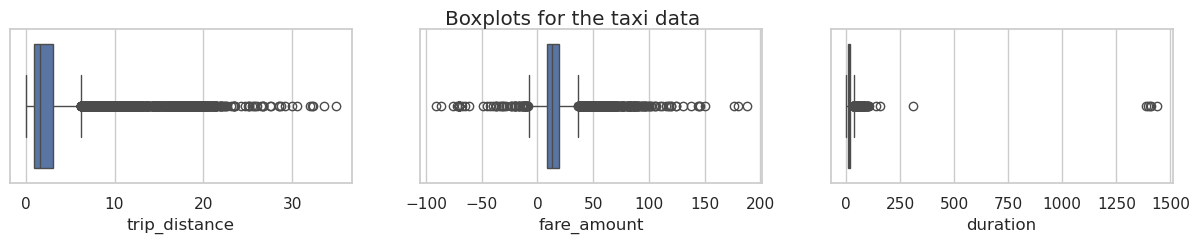

In [162]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for the taxi data')
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
plt.show();

## The trip distance column outliers
- the trip distance column have 532 zero values out of 25000 which will not have a huge impact on datset so the trip distance column remains same

In [163]:
sum(reduced_df['trip_distance']==0)

188

## Fare amount outlier

In [164]:
reduced_df['fare_amount'].describe()

count   10000.00
mean       17.96
std        17.25
min       -91.20
25%         8.60
50%        12.80
75%        19.80
max       187.80
Name: fare_amount, dtype: float64

In [165]:
def oulierDetect(name_list,factor):
    for x in name_list:
        # if values less than zeros are considered as zeros
        reduced_df.loc[reduced_df[x] < 0, x] = 0
        # seting q3 value
        q3 = reduced_df[x].quantile(0.75)
        # setting the upper cap
        upper_cap = q3 + (factor * (q3 - reduced_df[x].quantile(0.25)))
        
        reduced_df.loc[reduced_df[x] > upper_cap, x] = upper_cap


In [166]:
oulierDetect(['fare_amount'], 3)
reduced_df['fare_amount'].describe()

count   10000.00
mean       17.14
std        12.93
min         0.00
25%         8.60
50%        12.80
75%        19.80
max        53.40
Name: fare_amount, dtype: float64

## Duration Outlier detection
- changeing the factor to 4 for better predictions

In [167]:
oulierDetect(['duration'], 3)
reduced_df['duration'].describe()


count   10000.00
mean       14.56
std        10.75
min         0.00
25%         7.12
50%        11.52
75%        18.75
max        53.65
Name: duration, dtype: float64

In [168]:
reduced_df['pickDrop'] = reduced_df['PULocationID'].astype(str) + ' ' + reduced_df['DOLocationID'].astype(str)
reduced_df['pickDrop'].head(2)

1725696    132 233
1581136     163 75
Name: pickDrop, dtype: object

## Mean Distance Column

In [169]:
pickDrop_Dis = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['trip_distance']]
pickDrop_Dis[:10]

pickDrop_Dis_dict = pickDrop_Dis.to_dict()


pickDrop_Dis_dict = pickDrop_Dis_dict['trip_distance']

# len(pickDrop_Dis_dict)

reduced_df['mean_dis'] = reduced_df['pickDrop']


reduced_df['mean_dis'] = reduced_df['mean_dis'].map(pickDrop_Dis_dict)


reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_dis']]

,mean_dis
2779147,3.83


## Mean Duriation Column

In [170]:
grouped = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['duration']]
grouped

grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

reduced_df['mean_duration'] = reduced_df['pickDrop']
reduced_df['mean_duration'] = reduced_df['mean_duration'].map(grouped_dict)

reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_duration']]

,mean_duration
2779147,26.22


In [171]:

reduced_df['dd'] = reduced_df['tpep_pickup_datetime'].dt.day_name().str.lower()

reduced_df['mm'] = reduced_df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

reduced_df['dd']

1725696     saturday
1581136     thursday
19137         monday
1682810       friday
511035      saturday
             ...    
874720      thursday
1234009       monday
753040     wednesday
1784075     saturday
1834261       sunday
Name: dd, Length: 10000, dtype: object

In [172]:

reduced_df['peek_t'] = reduced_df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
reduced_df.loc[reduced_df['dd'].isin(['saturday', 'sunday']), 'peek_t'] = 0
def peek_analzer(hour):
    if 6 <= hour['peek_t'] < 10:
        val = 1
    elif 16 <= hour['peek_t'] < 20:
        val = 1
    else:
        val = 0
    return val
reduced_df['peek_t'] = reduced_df.apply(peek_analzer, axis=1)
reduced_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,duration,pickDrop,mean_dis,mean_duration,dd,mm,peek_t
1725696,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.00,17.14,2.00,N,132,233,1,...,90.96,2.50,1.75,31.92,132 233,17.29,27.74,saturday,jan,0
1581136,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.00,2.49,1.00,N,163,75,1,...,22.50,2.50,0.00,10.58,163 75,2.49,10.58,thursday,jan,0
19137,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.00,1.84,1.00,N,127,20,2,...,12.50,0.00,0.00,6.82,127 20,1.84,6.82,monday,jan,0
1682810,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.00,3.60,1.00,N,186,263,1,...,33.95,2.50,0.00,30.00,186 263,3.88,24.74,friday,jan,0
511035,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.00,0.04,1.00,N,238,238,2,...,6.20,0.00,0.00,1.57,238 238,0.38,3.63,saturday,jan,0


## The mean duration correlates with target value

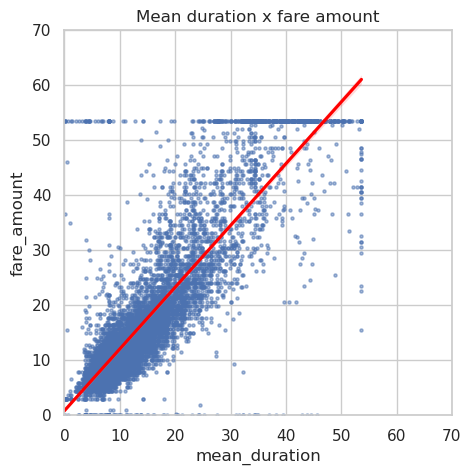

In [173]:
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=reduced_df['mean_duration'], y=reduced_df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

In [174]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1725696 to 1834261
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               10000 non-null  int32         
 1   tpep_pickup_datetime   10000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  10000 non-null  datetime64[us]
 3   passenger_count        9549 non-null   float64       
 4   trip_distance          10000 non-null  float64       
 5   RatecodeID             9549 non-null   float64       
 6   store_and_fwd_flag     9549 non-null   object        
 7   PULocationID           10000 non-null  int32         
 8   DOLocationID           10000 non-null  int32         
 9   payment_type           10000 non-null  int64         
 10  fare_amount            10000 non-null  float64       
 11  extra                  10000 non-null  float64       
 12  mta_tax                10000 non-null  float64       
 13

In [175]:
rdDf = reduced_df.copy()

rdDf = rdDf.drop(['tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration','Airport_fee',"congestion_surcharge","pickDrop","dd","mm"
               ], axis=1)
# filling missing values for passsenger count
rdDf['passenger_count'].fillna(1, inplace=True)

rdDf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1725696 to 1834261
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         10000 non-null  int32  
 1   passenger_count  10000 non-null  float64
 2   fare_amount      10000 non-null  float64
 3   mean_dis         10000 non-null  float64
 4   mean_duration    10000 non-null  float64
 5   peek_t           10000 non-null  int64  
dtypes: float64(4), int32(1), int64(1)
memory usage: 507.8 KB


/tmp/ipykernel_12402/143704564.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rdDf['passenger_count'].fillna(1, inplace=True)


In [176]:
rdDf.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
VendorID,1.00,0.11,0.02,0.03,-0.02,-0.01
passenger_count,0.11,1.00,0.02,0.02,0.02,-0.02
fare_amount,0.02,0.02,1.00,0.87,0.86,-0.01
mean_dis,0.03,0.02,0.87,1.00,0.85,-0.03
mean_duration,-0.02,0.02,0.86,0.85,1.00,-0.00
peek_t,-0.01,-0.02,-0.01,-0.03,-0.00,1.00


## Strongest Correlations:

- fare_amount with mean_dis (0.89)
- fare_amount with mean_duration (0.82)
- mean_dis with mean_duration (0.86)


diffrentiating X and y which is features and target

In [177]:

X = rdDf.drop(columns=['fare_amount'])

y = rdDf[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_dis,mean_duration,peek_t
1725696,2,2.00,17.29,27.74,0
1581136,2,1.00,2.49,10.58,0
19137,2,2.00,1.84,6.82,0
1682810,1,1.00,3.88,24.74,0
511035,2,1.00,0.38,3.63,0


In [178]:
X['VendorID'] = X['VendorID'].astype(str)

X = pd.get_dummies(X, drop_first=True)
X.isna().sum()

passenger_count    0
mean_dis           0
mean_duration      0
peek_t             0
VendorID_2         0
dtype: int64

## Training the data Linear regression
- Feature data set is -> VendorID	passenger_count	mean_dis	mean_duration	peek_t
- Target value is fare_amount

In [180]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [181]:

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = np.insert(X_train_scaled, 0, 1, axis=1)
print('X_train scaled:', X_train_scaled)
X_train.info()

X_train scaled: [[ 1.         -0.38643426  0.06644432  0.90332723 -0.67812537  0.57022934]
 [ 1.         -0.38643426  4.20136976  3.57964024 -0.67812537  0.57022934]
 [ 1.         -0.38643426 -0.53522991 -0.47919536 -0.67812537 -1.75368036]
 ...
 [ 1.          0.81320644 -0.45127984 -0.43221751 -0.67812537  0.57022934]
 [ 1.         -0.38643426 -0.53535341 -0.65653615 -0.67812537 -1.75368036]
 [ 1.          0.81320644 -0.54110201 -0.65812154  1.47465358  0.57022934]]
<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 1740287 to 2604597
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passenger_count  8000 non-null   float64
 1   mean_dis         8000 non-null   float64
 2   mean_duration    8000 non-null   float64
 3   peek_t           8000 non-null   int64  
 4   VendorID_2       8000 non-null   bool   
dtypes: bool(1), float64(3), int64(1)
memory usage: 320.3 KB


In [182]:
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [183]:
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8177217457212991
R^2: 0.8177217457212991
MAE: 3.18325693411646
MSE: 30.519239711871464
RMSE: 5.524422115648972


In [142]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = np.insert(X_test_scaled, 0, 1, axis=1)

In [143]:
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.7842014476004773
R^2: 0.7842014476004773
MAE: 3.465383500399583
MSE: 37.85415440102934
RMSE: 6.152572990304897


In [144]:
import statsmodels.api as sm
scale = StandardScaler()
y1 = rdDf[['fare_amount']]
X1 = rdDf.drop(columns=['fare_amount'])
X1['VendorID'] = X1['VendorID'].astype(int)
X1[['VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']] = scale.fit_transform(X1[[ 'VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']].values)
X1 = sm.add_constant(X1)

# print (X)
est = sm.OLS(y1, X1).fit()

print(est.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                 1.932e+04
Date:                Thu, 18 Jul 2024   Prob (F-statistic):               0.00
Time:                        11:50:30   Log-Likelihood:                -79955.
No. Observations:               25000   AIC:                         1.599e+05
Df Residuals:                   24994   BIC:                         1.600e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              17.2356      0.037    4

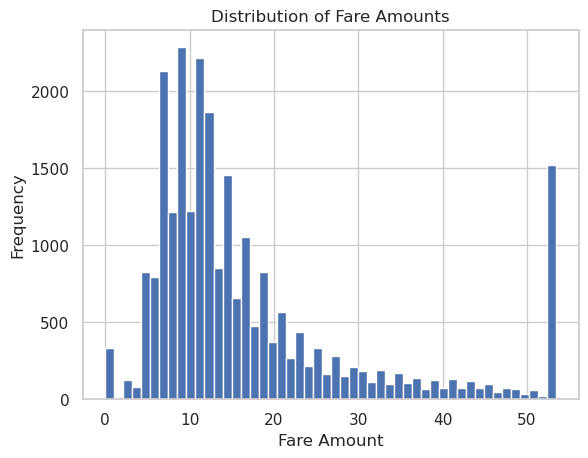

In [145]:

plt.hist(rdDf['fare_amount'], bins=50)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amounts')
plt.show()

In [146]:
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
20929,10.00,11.96,-1.96
117321,53.48,10.98,42.50
741403,11.40,16.15,-4.75
109663,53.48,43.16,10.32
1531687,7.90,9.29,-1.39


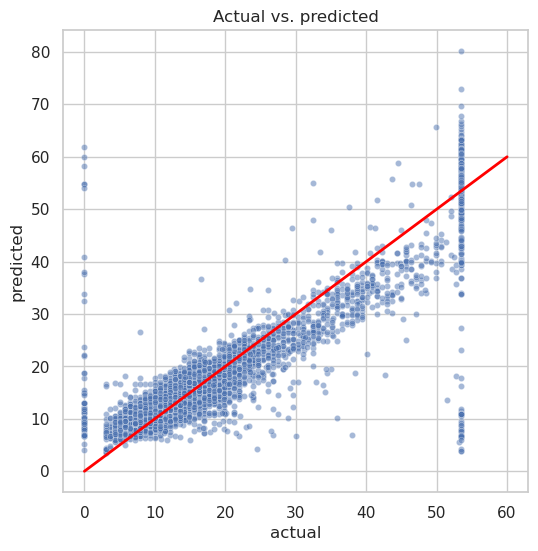

In [147]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

In [148]:
results['residual'].mean()

-0.03214147015960922

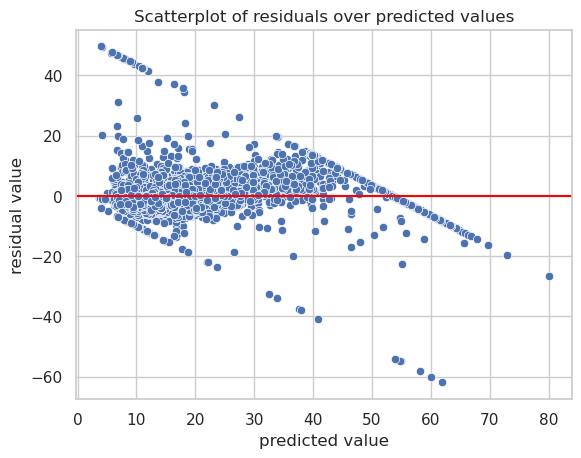

In [149]:
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

In [150]:
# coefficients = pd.DataFrame(lr.coef_, columns=X.columns)
# coefficients
feature_names_with_constant = ['constant'] + X.columns.tolist()

# Create the DataFrame for coefficients
coefficients = pd.DataFrame(lr.coef_, columns=feature_names_with_constant)

print(coefficients)

   constant  passenger_count  mean_dis  mean_duration  peek_t  VendorID_2
0      0.00             0.15      6.45           5.59    0.01        0.17


In [151]:
print(X_train['mean_dis'].std())


print(11.24 / X_train['mean_dis'].std())
rdDf[rdDf['fare_amount'] == 30][:1]

4.173212314721292
2.693368837322302


,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
700891,2,1.00,30.00,0.31,4.18,0


In [152]:
scaled = scaler.transform([[2,1.00,0.31,4.18,0]])
# 	VendorID	passenger_count	fare_amount	mean_dis	mean_duration	peek_t
feature_names = ['VendorID', 'passenger_count', 'mean_dis', 'mean_duration', 'peek_t']
res = pd.DataFrame(scaled,columns=feature_names)
res.insert(0, 'constant', 1)
# scaled = np.insert(scaled[0], 0, 1) #Need to add that constant column in again.
print(res)

predicted = lr.predict(res)
print(predicted)

   constant  VendorID  passenger_count  mean_dis  mean_duration  peek_t
0         1      0.84            -0.53     -1.48           8.38   -1.73
[[5.53013653]]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [69]:
import boto3

# Create a SageMaker client
sagemaker_client = boto3.client('sagemaker')

# Describe the notebook instance
response = sagemaker_client.describe_notebook_instance(NotebookInstanceName='CFNNotebookInstance-Xa92mgFXrAj5')

# Get the execution role ARN
role_arn = response['RoleArn']
print(role_arn)

arn:aws:iam::765548118789:role/c124716a3072539l7097115t1w76-SageMakerExecutionRole-eW4tRf9IjD2S


In [86]:
import joblib
import tarfile
import boto3


# Create a tar.gz archive
with tarfile.open('lr.tar.gz', 'w:gz') as tar:
    tar.add('lr.joblib', arcname='lr.joblib')


s3 = boto3.client('s3')
s3.upload_file('lr.tar.gz', 'cml1550', 'lr.tar.gz')
# Save the model to S3
# s3 = boto3.client('s3')
# joblib.dump(lr, 'lr.joblib')
# s3.upload_file('lr.joblib', 'cml1550', 'lr.joblib')

In [109]:
import sagemaker
from sagemaker.sklearn import SKLearnModel

role = 'arn:aws:iam::765548118789:role/c124716a3072539l7097115t1w76-SageMakerExecutionRole-eW4tRf9IjD2S'
framework_version = '0.23-1'
py_version = 'py3'

model = SKLearnModel(model_data='s3://cml1550/lr.joblib',
                     role=role,
                     entry_point='inference.py',framework_version=framework_version,
                     py_version=py_version)  # Your inference script
print(model)

In [ ]:
predictor = model.deploy(initial_instance_count=1, instance_type='ml.m4.xlarge')

----

In [79]:
import json

data = json.dumps([[2,1.00,0.31,4.18,0]])  # Example input data
response = predictor.predict(data)
print(response)

ModelError: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (500) from primary with message "<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>
". See https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#logEventViewer:group=/aws/sagemaker/Endpoints/sagemaker-scikit-learn-2024-07-18-06-59-25-340 in account 765548118789 for more information.

In [104]:
import os
def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, 'lr.joblib'))
    return model
print(os.path)

<module 'posixpath' from '/home/ec2-user/anaconda3/envs/python3/lib/python3.10/posixpath.py'>


In [103]:
model_fn('CML_CA')

FileNotFoundError: [Errno 2] No such file or directory: 'CML_CA/lr.joblib'